In [1]:
import pickle
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import faiss


with open("ESM3_function_terms_idf.pkl", "rb") as f:
    function_terms_idf = pickle.load(f)

def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    intersection_weight = sum([function_terms_idf[x] for x in s1.intersection(s2)])
    union_weight = sum([function_terms_idf[x] for x in s1.union(s2)])
    return intersection_weight / union_weight

    # return len(s1.intersection(s2)) / len(s1.union(s2))

In [3]:
print(f"TF-IDF min {np.min(list(function_terms_idf.values()))}, max {np.max(list(function_terms_idf.values()))}, mean {np.mean(list(function_terms_idf.values()))}, median {np.median(list(function_terms_idf.values()))}")

TF-IDF min 4.5070705863853, max 10.773321917959331, mean 10.272370745251802, median 10.773321917959331


## sanity check
within the embedding space, KNN should have higher functional similarity than random NN

In [26]:
data = []
for i in range(16):
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/QBioLiP_ESM3/PRNA_{i}.pkl", "rb") as f:
        data.extend(pickle.load(f))

function_count = Counter(sum([list(item['segment0_functions']) for item in data] , []))
print("number of functions", len(function_count))
top100_functions = [x[0] for x in function_count.most_common(50)]
function_count

number of functions 2868


Counter({'heterocyclic': 708,
         'heterocyclic compound': 708,
         'molecule binding': 706,
         'phosphate binding': 671,
         'nucleotide binding': 656,
         'trna': 628,
         'on rna': 535,
         'anion binding': 532,
         'a nucleic': 528,
         'polymerase': 525,
         'beta': 500,
         'derivative binding': 491,
         'purine': 489,
         'ribonucleotide': 488,
         'purine nucleotide': 488,
         'translation': 481,
         'adenyl nucleotide': 463,
         'adenyl': 463,
         'triphosphate': 458,
         'ribonucleoside': 456,
         'ribonucleotide binding': 455,
         'purine ribonucleotide': 441,
         'ribonucleoside triphosphate': 439,
         'amide': 431,
         'atp binding': 428,
         'purine ribonucleoside': 416,
         'ligase': 415,
         'rna binding': 414,
         'amide metabolic': 409,
         'triphosphate binding': 394,
         'peptide': 391,
         'peptide metabolic': 3

### how to improve
The functions are unigrams and bigrams, so some of them are very useless e.g. 'the' is not useful. We need to remove them (possibly using TFIDF), for now I just used a fix of keeping only the topk most common words.

In [27]:
function_key = 'segment0_functions'

filtered_data = []
for x in data:
    if len(x[function_key]) > 0: # and len(set(x[function_key]) & set(top100_functions)) > 0:
        filtered_data.append(x)

filtered_data_dict = {x['id']: x for x in filtered_data}
len(filtered_data), len(data)

(952, 3523)

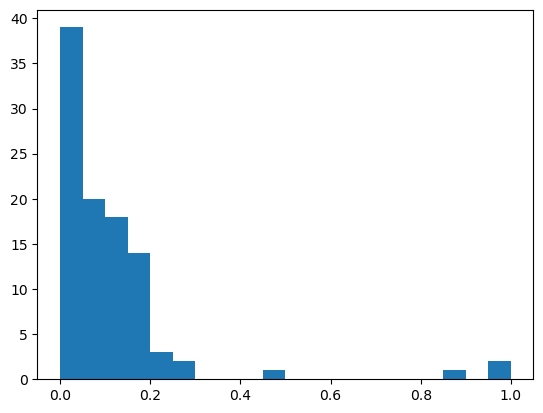

In [28]:
import random
pairs = zip(random.sample(filtered_data, min(100, len(filtered_data))), random.sample(filtered_data, min(100, len(filtered_data))))
jaccard_similarity_list = []
for pair in pairs:
    jaccard_similarity_list.append(jaccard_similarity(pair[0]['segment0_functions'], pair[1]['segment0_functions']))

plt.hist(jaccard_similarity_list, bins=20)
plt.show()

In [29]:
embeddings_dir = "/n/holyscratch01/mzitnik_lab/afang/InteractNN_embeddings/prot_interface_version_16_epoch16_step97495/"
pdb_embeddings_file = f"{embeddings_dir}/PRNA_nonredund.pkl"
with open(pdb_embeddings_file, 'rb') as f:
    pdb_embeddings = pickle.load(f)
pdb_embeddings = {x['id']: x for x in pdb_embeddings}

ids = set(pdb_embeddings.keys()).intersection(set(filtered_data_dict.keys()))

/tmp/ipykernel_2097259/3028849839.py:1: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  pairs = zip(random.sample(ids, min(100, len(filtered_data))), random.sample(ids, min(100, len(filtered_data))))


Text(0, 0.5, 'Embedding cosine similarity')

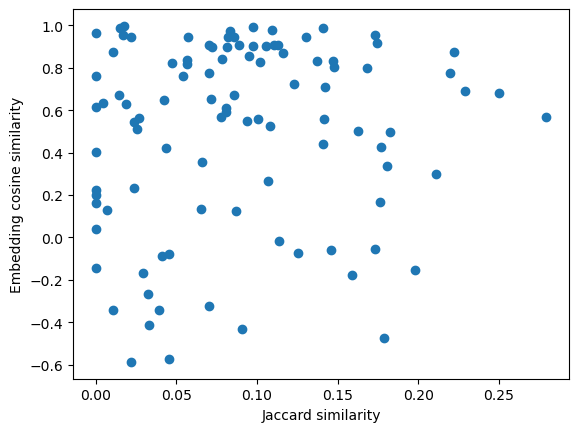

In [30]:
pairs = zip(random.sample(ids, min(100, len(filtered_data))), random.sample(ids, min(100, len(filtered_data))))
jaccard_similarity_list = []
embedding_dist = []
for pair in pairs:
    jaccard_similarity_list.append(jaccard_similarity(filtered_data_dict[pair[0]][function_key],filtered_data_dict[pair[1]][function_key]))
    embedding_dist.append(np.dot(pdb_embeddings[pair[0]]['graph_embedding'], pdb_embeddings[pair[1]]['graph_embedding']))
    # embedding_dist.append(np.linalg.norm(pdb_embeddings[pair[0]]['graph_embedding'] - pdb_embeddings[pair[1]]['graph_embedding']))

plt.scatter(jaccard_similarity_list, embedding_dist)
plt.xlabel("Jaccard similarity")
plt.ylabel("Embedding cosine similarity")

KNN: 0.1630812156445688, Random: 0.09553318889152798


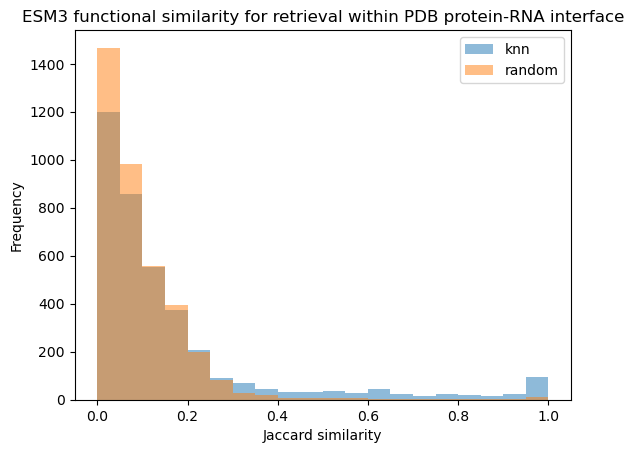

In [34]:
ids_list = list(ids)
embeddings = np.array([pdb_embeddings[x]['graph_embedding'] for x in ids_list])
faiss_index = faiss.IndexFlatIP(embeddings.shape[1])
faiss_index.add(embeddings)

k = 5
knn_functional_similarity = []
for i in range(embeddings.shape[0]):
    D, I = faiss_index.search(embeddings[i:i+1], k)
    for neigh in I[0][1:]:
        knn_functional_similarity.append(jaccard_similarity(filtered_data_dict[ids_list[i]][function_key], filtered_data_dict[ids_list[neigh]][function_key]))

random_functional_similarity = []
for i in range(embeddings.shape[0]):
    for j in range(k-1):
        j = random.choice(range(embeddings.shape[0]))
        random_functional_similarity.append(jaccard_similarity(filtered_data_dict[ids_list[i]][function_key], filtered_data_dict[ids_list[j]][function_key]))

print(f"KNN: {np.mean(knn_functional_similarity)}, Random: {np.mean(random_functional_similarity)}")    

plt.hist(knn_functional_similarity, bins=20, alpha=0.5, label='knn')
plt.hist(random_functional_similarity, bins=20, alpha=0.5, label='random')
plt.legend(loc='upper right')
plt.xlabel("Jaccard similarity")
plt.ylabel("Frequency")
plt.title("ESM3 functional similarity for retrieval within PDB protein-RNA interface")
plt.show()

## Dark proteome

A couple ways to improve this:
* see if using TFIDF embeddings does better, to weight the more important words more
* ignore the dark proteome and focus only on uniprot proteins with annotation scores >= 3

### Protein-nucleic

In [13]:
embeddings_dir = "/n/holyscratch01/mzitnik_lab/afang/InteractNN_embeddings/prot_interface_version_16_epoch16_step97495/"
query_data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/"

def get_mean_block_embedding(item):
    return item['graph_embedding']

pesto_cutoff=60
query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_{pesto_cutoff}_nucleic_acid.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)
query_embeddings_ids = [x['id'] for x in query_embeddings]
query_embeddings = {x['id']: x for x in query_embeddings}

query_data_file = f"{query_data_dir}/is_dark_90_plddt_PeSTo_{pesto_cutoff}_nucleic_acid.pkl"
with open(query_data_file, 'rb') as f:
    query_dataset = pickle.load(f)
query_dataset = {x['id']:x for x in query_dataset}

rna_embeddings_file = f"{embeddings_dir}/PRNA_nonredund.pkl"
with open(rna_embeddings_file, 'rb') as f:
    rna_embeddings = pickle.load(f)
rna_embeddings_ids = [x['id'] for x in rna_embeddings]
rna_embeddings = {x['id']: x for x in rna_embeddings}

dna_embeddings_file = f"{embeddings_dir}/PDNA_nonredund.pkl"
with open(dna_embeddings_file, 'rb') as f:
    dna_embeddings = pickle.load(f)
dna_embeddings_ids = [x['id'] for x in dna_embeddings]
dna_embeddings = {x['id']: x for x in dna_embeddings}

In [14]:
function_key = 'segment0_functions'

rna_functions = []
for i in range(16):
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/QBioLiP_ESM3/PRNA_{i}.pkl", "rb") as f:
        rna_functions.extend(pickle.load(f))
rna_functions = [x for x in rna_functions if len(x[function_key]) > 0]
rna_functions_ids = [x['id'] for x in rna_functions]

dna_functions = []
for i in range(16):
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/QBioLiP_ESM3/PDNA_{i}.pkl", "rb") as f:
        dna_functions.extend(pickle.load(f))
dna_functions = [x for x in dna_functions if len(x[function_key]) > 0]
dna_functions_ids = [x['id'] for x in dna_functions]

with open("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/is_dark_90_plddt/is_dark_90_plddt_PeSTo_80_nucleic_acid_ESM3_functions.pkl", "rb") as f:
    query_functions = pickle.load(f)
query_functions = [x for x in query_functions if len(x[function_key]) > 0]
query_functions_ids = [x['id'] for x in query_functions]
query_functions = {x['id']: x for x in query_functions}

rna_ids = list(set(rna_embeddings_ids).intersection(set(rna_functions_ids)))
dna_ids = list(set(dna_embeddings_ids).intersection(set(dna_functions_ids)))
query_ids = list(set(query_embeddings_ids).intersection(set(query_functions_ids)))

print(f"RNA: embeddings {len(rna_embeddings_ids)}, functions {len(rna_functions_ids)}, intersection {len(rna_ids)}")
print(f"DNA: embeddings {len(dna_embeddings_ids)}, functions {len(dna_functions_ids)}, intersection {len(dna_ids)}")
print(f"Query: embeddings {len(query_embeddings_ids)}, functions {len(query_functions_ids)}, intersection {len(query_ids)}")

RNA: embeddings 3511, functions 952, intersection 948
DNA: embeddings 2750, functions 1742, intersection 1736
Query: embeddings 4817, functions 2699, intersection 2699


In [15]:
query_pocket_size = [len(query_dataset[query_id]['block_to_pdb_indexes']) for query_id in query_ids]
print(f"Query pocket size: mean {np.mean(query_pocket_size)}, median {np.median(query_pocket_size)}, min {np.min(query_pocket_size)}, max {np.max(query_pocket_size)}")

with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024/PRNA_nonredund.pkl", "rb") as f:
    rna_data = pickle.load(f)
rna_pocket_size = [len(item['data']['B'])-sum(item['data']['segment_ids'])-1 for item in rna_data]
print(f"RNA pocket size: mean {np.mean(rna_pocket_size)}, median {np.median(rna_pocket_size)}, min {np.min(rna_pocket_size)}, max {np.max(rna_pocket_size)}")

with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024/PDNA_nonredund.pkl", "rb") as f:
    dna_data = pickle.load(f)
dna_pocket_size = [len(item['data']['B'])-sum(item['data']['segment_ids'])-1 for item in dna_data]
print(f"DNA pocket size: mean {np.mean(dna_pocket_size)}, median {np.median(dna_pocket_size)}, min {np.min(dna_pocket_size)}, max {np.max(dna_pocket_size)}")

Query pocket size: mean 26.374953686550576, median 23.0, min 6, max 179


RNA pocket size: mean 74.79236684705212, median 39.0, min 1, max 1096
DNA pocket size: mean 67.156, median 54.0, min 1, max 457


In [22]:
ids_list = rna_ids + dna_ids
pdb_functions = [rna_functions[rna_functions_ids.index(x)] for x in rna_ids] + [dna_functions[dna_functions_ids.index(x)] for x in dna_ids]

embeddings = np.array([get_mean_block_embedding(rna_embeddings[x]) for x in rna_ids] + [get_mean_block_embedding(dna_embeddings[x]) for x in dna_ids])
faiss_index = faiss.IndexFlatIP(embeddings.shape[1])
faiss_index.add(embeddings)

import random
random.seed(42)

k = 5
knn_functional_similarity = []
random_functional_similarity = []
for query_idx, query_id in enumerate(query_ids):
    query_embedding = get_mean_block_embedding(query_embeddings[query_id])
    D, I = faiss_index.search(query_embedding.reshape(1, -1), k)
    for neigh in I[0]:
        knn_functional_similarity.append(jaccard_similarity(pdb_functions[neigh][function_key], query_functions[query_id][function_key]))
    for j in range(k):
        j = random.choice(range(embeddings.shape[0]))
        random_functional_similarity.append(jaccard_similarity(pdb_functions[j][function_key], query_functions[query_id][function_key]))

print(f"KNN: {np.mean(knn_functional_similarity)}, Random: {np.mean(random_functional_similarity)}")

KNN: 0.0829179185343869, Random: 0.08858450070513554


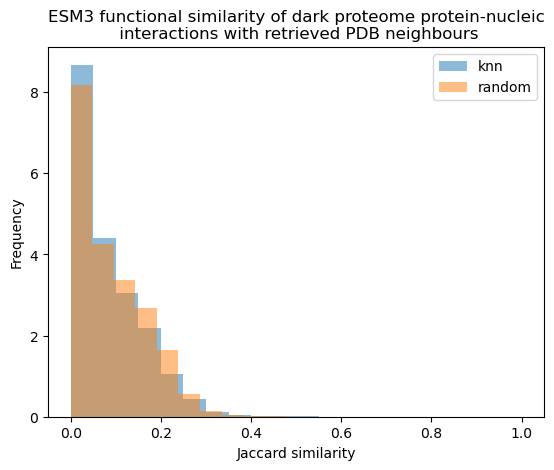

In [23]:
plt.hist(knn_functional_similarity, bins=20, alpha=0.5, label='knn', density=True)
plt.hist(random_functional_similarity, bins=20, alpha=0.5, label='random', density=True)
plt.legend(loc='upper right')
plt.xlabel("Jaccard similarity")
plt.ylabel("Frequency")
plt.title("ESM3 functional similarity of dark proteome protein-nucleic\n interactions with retrieved PDB neighbours")
plt.show()

In [24]:
ids_list = rna_ids + dna_ids
pdb_functions = [rna_functions[rna_functions_ids.index(x)] for x in rna_ids] + [dna_functions[dna_functions_ids.index(x)] for x in dna_ids]

embeddings = np.array([get_mean_block_embedding(rna_embeddings[x]) for x in rna_ids] + [get_mean_block_embedding(dna_embeddings[x]) for x in dna_ids])
faiss_index = faiss.IndexFlatL2(embeddings.shape[1])
faiss_index.add(embeddings)

import random
random.seed(42)

k = 3
knn_functional_similarity = []
random_functional_similarity = []
for query_idx, query_id in enumerate(query_ids):
    query_embedding = get_mean_block_embedding(query_embeddings[query_id])
    D, I = faiss_index.search(query_embedding.reshape(1, -1), k)
    for neigh in I[0]:
        knn_functional_similarity.append(jaccard_similarity(pdb_functions[neigh][function_key], query_functions[query_id][function_key]))
    for j in range(k):
        j = random.choice(range(embeddings.shape[0]))
        random_functional_similarity.append(jaccard_similarity(pdb_functions[j][function_key], query_functions[query_id][function_key]))

print(f"KNN: {np.mean(knn_functional_similarity)}, Random: {np.mean(random_functional_similarity)}")

KNN: 0.08342073461198325, Random: 0.08760729067301269


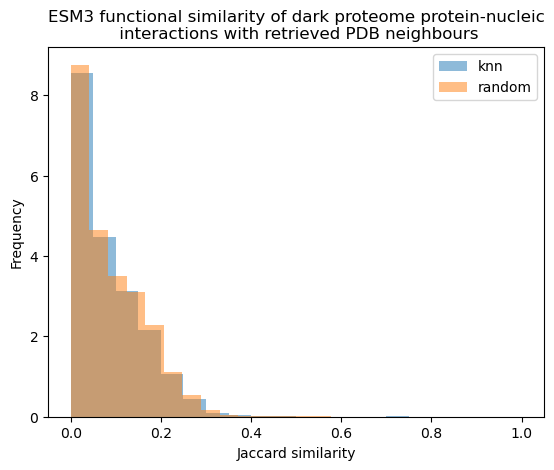

In [25]:
plt.hist(knn_functional_similarity, bins=20, alpha=0.5, label='knn', density=True)
plt.hist(random_functional_similarity, bins=20, alpha=0.5, label='random', density=True)
plt.legend(loc='upper right')
plt.xlabel("Jaccard similarity")
plt.ylabel("Frequency")
plt.title("ESM3 functional similarity of dark proteome protein-nucleic\n interactions with retrieved PDB neighbours")
plt.show()

### Protein-protein

In [35]:
embeddings_dir = "/n/holyscratch01/mzitnik_lab/afang/InteractNN_embeddings/prot_interface_version_16_epoch16_step97495/"
query_data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/"

def get_mean_block_embedding(item):
    return item['graph_embedding']

query_embeddings_file = f"{embeddings_dir}/is_dark_90_plddt_PeSTo_80_protein.pkl"
with open(query_embeddings_file, 'rb') as f:
    query_embeddings = pickle.load(f)
query_embeddings_ids = [x['id'] for x in query_embeddings]
query_embeddings = {x['id']: x for x in query_embeddings}

query_data_file = f"{query_data_dir}/is_dark_90_plddt_PeSTo_80_protein.pkl"
with open(query_data_file, 'rb') as f:
    query_dataset = pickle.load(f)
query_dataset = {x['id']:x for x in query_dataset}

pp_embeddings_file = f"{embeddings_dir}/PP_nonredund_fixed_ids.pkl"
with open(pp_embeddings_file, 'rb') as f:
    pp_embeddings = pickle.load(f)
pp_embeddings_ids = [x['id'] for x in pp_embeddings]
pp_embeddings = {x['id']: x for x in pp_embeddings}

In [ ]:
function_key = 'segment0_functions'

pp_functions = []
for i in range(13):
    with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/QBioLiP_ESM3/PP_{i}.pkl", "rb") as f:
        pp_functions.extend(pickle.load(f))
pp_functions = [x for x in pp_functions if len(x[function_key]) > 0]
pp_functions_ids = [x['id'] for x in pp_functions]

with open("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/is_dark_90_plddt/is_dark_90_plddt_PeSTo_80_protein_ESM3_functions.pkl", "rb") as f:
    query_functions = pickle.load(f)
query_functions = [x for x in query_functions if len(x[function_key]) > 0]
query_functions_ids = [x['id'] for x in query_functions]
query_functions = {x['id']: x for x in query_functions}

pp_ids = list(set(pp_embeddings_ids).intersection(set(pp_functions_ids)))
query_ids = list(set(query_embeddings_ids).intersection(set(query_functions_ids)))

print(f"PP: embeddings {len(pp_embeddings_ids)}, functions {len(pp_functions_ids)}, intersection {len(pp_ids)}")
print(f"Query: embeddings {len(query_embeddings_ids)}, functions {len(query_functions_ids)}, intersection {len(query_ids)}")

In [ ]:
query_pocket_size = [len(query_dataset[query_id]['block_to_pdb_indexes']) for query_id in query_ids]
print(f"Query pocket size: mean {np.mean(query_pocket_size)}, median {np.median(query_pocket_size)}, min {np.min(query_pocket_size)}, max {np.max(query_pocket_size)}")

with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024/PP_nonredund_fixed_ids.pkl", "rb") as f:
    pp_data = pickle.load(f)
pp_pocket_size = [len(item['data']['B'])-sum(item['data']['segment_ids'])-1 for item in pp_data]
print(f"pp pocket size: mean {np.mean(pp_pocket_size)}, median {np.median(pp_pocket_size)}, min {np.min(pp_pocket_size)}, max {np.max(pp_pocket_size)}")

In [ ]:
ids_list = pp_ids
pdb_functions = [pp_functions[rna_functions_ids.index(x)] for x in pp_ids]

embeddings = np.array([get_mean_block_embedding(pp_embeddings[x]) for x in pp_ids])
faiss_index = faiss.IndexFlatIP(embeddings.shape[1])
faiss_index.add(embeddings)

import random
random.seed(42)

k = 5
knn_functional_similarity = []
random_functional_similarity = []
for query_idx, query_id in enumerate(query_ids):
    query_embedding = get_mean_block_embedding(query_embeddings[query_id])
    D, I = faiss_index.search(query_embedding.reshape(1, -1), k)
    for neigh in I[0]:
        knn_functional_similarity.append(jaccard_similarity(pdb_functions[neigh][function_key], query_functions[query_id][function_key]))
    for j in range(k):
        j = random.choice(range(embeddings.shape[0]))
        random_functional_similarity.append(jaccard_similarity(pdb_functions[j][function_key], query_functions[query_id][function_key]))

print(f"KNN: {np.mean(knn_functional_similarity)}, Random: {np.mean(random_functional_similarity)}")

## Annotated Proteome

In [1]:
import pickle

with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/processed/annotated_uniprot_PeSTo_80_nucleic_acid.pkl", "rb") as f:
    pn_data = pickle.load(f)

In [7]:
import numpy as np
block_len = [len(x['block_to_pdb_indexes']) for x in pn_data]
np.mean(block_len), np.median(block_len), np.min(block_len), np.max(block_len)

(33.92483616423699, 23.0, 6, 336)

## Get functional annotations using ESM3

In [1]:
import os
os.environ['HF_HOME'] = '/n/holystore01/LABS/mzitnik_lab/Lab/afang/huggingface_cache'
import torch
from esm.models.esm3 import ESM3
from esm.sdk.api import ESMProtein, ESMProteinTensor, SamplingConfig, SamplingTrackConfig
from esm.utils.constants.models import ESM3_OPEN_SMALL
from esm.utils.structure.protein_chain import ProteinChain
from typing import List
from atom3d.datasets import LMDBDataset
from tqdm import tqdm
import pickle
import numpy as np
import biotite.structure as bs
from biotite.structure import AtomArray, get_residue_starts
import pickle
import numpy as np

CLIENT = ESM3.from_pretrained(ESM3_OPEN_SMALL, device=torch.device("cuda"))

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
        'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
        'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
        'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M', 
        'UNK': '?'}

/n/home13/afang/.conda/envs/esm3_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/n/home13/afang/.conda/envs/esm3_env/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


torch geometric not found, GNN examples will not work until it is.


Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 3004.61it/s]
/n/home13/afang/.conda/envs/esm3_env/lib/python3.10/site-packages/esm/pretrained.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to

In [9]:
tfidf_model = CLIENT.tokenizers.function._tfidf
vocab_to_idf = {k: tfidf_model.idf_[v] for k, v in tfidf_model.vocab_to_index.items()}
with open("ESM3_function_terms_idf.pkl", "wb") as f:
    pickle.dump(vocab_to_idf, f)

In [2]:
def get_chunk_idxs(
    seq_len: int,
    max_len: int,
) -> List[int]:
    num_pieces = (seq_len + max_len - 1) // max_len
    lo_size = seq_len // num_pieces
    hi_size = lo_size + 1
    num_hi = seq_len % num_pieces

    chunk_lens = [hi_size for _ in range(num_hi)] + [lo_size for _ in range(num_pieces - num_hi)]

    chunk_idxs = []
    curr = 0
    for chunk_len in chunk_lens:
        chunk_idxs.append((curr, curr+chunk_len))
        curr += chunk_len
    return chunk_idxs

def encode_one_protein(bs_atoms_array, max_len:int = 2048):
    protein_chain=ProteinChain.from_atomarray(bs_atoms_array)
    unique_chain_ids = np.unique(bs_atoms_array.chain_id)
    if len(unique_chain_ids) > 1:
        print("WARNING: more than one chain, will only embed the first chain")
    protein = ESMProtein.from_protein_chain(protein_chain)
    seq_len = len(protein.sequence)
    idxs = get_chunk_idxs(seq_len+2, max_len=max_len) # + 2 for EOS and BOS
    protein_tensor = CLIENT.encode(protein).to("cpu")

    outputs = []
    for (start, end) in idxs:
        sub_tensor = ESMProteinTensor(
            sequence=protein_tensor.sequence[start:end],
            structure=protein_tensor.structure[start:end],
            coordinates=protein_tensor.coordinates[start:end],
        ).to("cuda")
        output = CLIENT.forward_and_sample(
            sub_tensor, SamplingConfig(return_per_residue_embeddings=True)
        )
        outputs.append(output.per_residue_embedding.detach().cpu())
    outputs = torch.cat(outputs)
    assert outputs.shape[0] == seq_len+2, f"outputs shape {outputs.shape} != {seq_len+2}"
    return outputs[1:-1], protein.sequence

In [9]:
def function_annotation(pdb_path, chain_id):
    sampling_config = SamplingConfig(function=SamplingTrackConfig(only_sample_masked_tokens=False))
    protein_chain = ProteinChain.from_pdb(pdb_path, chain_id=chain_id)
    protein = ESMProtein.from_protein_chain(protein_chain)
    protein_tensor = CLIENT.encode(protein).to("cpu")
    sub_tensor = ESMProteinTensor(
        sequence=protein_tensor.sequence,
        structure=protein_tensor.structure,
        coordinates=protein_tensor.coordinates,
    ).to("cuda")
    output = CLIENT.forward_and_sample(
        sub_tensor, sampling_config
    )
    decoded_function = CLIENT.get_function_decoder().decode(
        output.protein_tensor.function,
        tokenizer=CLIENT.tokenizers.function,
    )
    interpro_keywords = decoded_function["function_keywords"]
    # TODO: could filter the interpro key words to only cover those at the interface
    tfidf_embedding = CLIENT.tokenizers.function._tfidf.encode(decoded_function["function_keywords"])
    return protein_tensor, interpro_keywords, tfidf_embedding, output.protein_tensor.function


In [10]:
pdb_path = "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PRNA/nonredund_rec/1s03_2.pdb"
chain_id = 'A'
protein_tensor1, interpro_keywords1, tfidf_embedding1, lsh_embedding1 = function_annotation(pdb_path, chain_id)

In [23]:
interpro_keywords1

[FunctionAnnotation(label='amide', start=2, end=126),
 FunctionAnnotation(label='amide biosynthetic', start=1, end=126),
 FunctionAnnotation(label='amide metabolic', start=1, end=126),
 FunctionAnnotation(label='constituent', start=1, end=126),
 FunctionAnnotation(label='constituent of', start=1, end=126),
 FunctionAnnotation(label='dna templated', start=1, end=82),
 FunctionAnnotation(label='dna templated', start=84, end=96),
 FunctionAnnotation(label='dna templated', start=103, end=103),
 FunctionAnnotation(label='dna templated', start=114, end=126),
 FunctionAnnotation(label='intracellular non', start=1, end=126),
 FunctionAnnotation(label='ligase', start=1, end=96),
 FunctionAnnotation(label='ligase', start=115, end=116),
 FunctionAnnotation(label='ligase', start=118, end=119),
 FunctionAnnotation(label='ligase', start=123, end=126),
 FunctionAnnotation(label='molecule activity', start=1, end=126),
 FunctionAnnotation(label='non', start=1, end=126),
 FunctionAnnotation(label='non m

In [26]:
def find_interface_annotations(annotations, interface_indexes):
    annotations.sort(key=lambda x: x.end)
    interface_annotations = set()
    for point in interface_indexes:
        for annotation in annotations:
            if annotation.start <= point <= annotation.end:
                interface_annotations.add(annotation.label)
            elif point > annotation.end:
                break
    return interface_annotations

interface_interprokeywords = find_interface_annotations(interpro_keywords1, [10, 20, 30, 200])

In [32]:
import pickle
with open("/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/processed2/PRNA/PRNA_0.pkl", "rb") as f:
    data = pickle.load(f)

In [33]:
data[0].keys()

dict_keys(['id', 'affinity', 'data', 'block_to_pdb_indexes', 'dist_th', 'atom_array1', 'atom_array2'])

In [27]:
interface_interprokeywords

{'amide',
 'amide biosynthetic',
 'amide metabolic',
 'constituent',
 'constituent of',
 'dna templated',
 'intracellular non',
 'ligase',
 'molecule activity',
 'non',
 'non membrane',
 'of ribosome',
 'peptide',
 'peptide biosynthetic',
 'peptide metabolic',
 'polymerase',
 'regulator activity',
 'ribosomal',
 'ribosomal subunit',
 'ribosome',
 'rna binding',
 'rna biosynthetic',
 'structural',
 'structural constituent',
 'structural molecule',
 'subunit protein',
 'templated',
 'templated transcription',
 'transcription regulator',
 'translation',
 'trna'}

In [20]:
tfidf_embedding1.shape

(1, 58641)

In [72]:
pdb_path = "/n/holyscratch01/mzitnik_lab/afang/raw_QBioLiP_06_2024/PRNA/nonredund_rec/1m8v_1.pdb"
chain_id = 'A'
interpro_keywords2, tfidf_embedding2 = function_annotation(pdb_path, chain_id)

/n/home13/afang/.conda/envs/esm3_env/lib/python3.10/site-packages/esm/models/vqvae.py:289: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):  # type: ignore


In [74]:
func_annotations = [(CLIENT.tokenizers.function.keyword_to_index[annot.label], annot) for annot in interpro_keywords1]
func_annotations[:10]

[(4136, FunctionAnnotation(label='amide', start=1, end=126)),
 (4138, FunctionAnnotation(label='amide biosynthetic', start=1, end=126)),
 (4142, FunctionAnnotation(label='amide metabolic', start=1, end=126)),
 (12028, FunctionAnnotation(label='constituent', start=1, end=126)),
 (12030, FunctionAnnotation(label='constituent of', start=1, end=126)),
 (15609, FunctionAnnotation(label='dna templated', start=1, end=82)),
 (15609, FunctionAnnotation(label='dna templated', start=84, end=96)),
 (15609, FunctionAnnotation(label='dna templated', start=103, end=103)),
 (15609, FunctionAnnotation(label='dna templated', start=114, end=126)),
 (26076, FunctionAnnotation(label='intracellular non', start=1, end=126))]

In [64]:
def cosine_similarity_sparse_vectors(a, b):
    # Compute the dot product
    dot_product = a.dot(b.T).A[0, 0]  # A[0, 0] extracts the scalar value
    
    # Compute the norms
    norm_a = np.sqrt(a.power(2).sum())
    norm_b = np.sqrt(b.power(2).sum())
    
    # Compute cosine similarity
    if norm_a == 0 or norm_b == 0:
        return 0.0  # Handle the case of zero vectors
    else:
        return dot_product / (norm_a * norm_b)

In [77]:
sim = cosine_similarity_sparse_vectors(tfidf_embedding1, tfidf_embedding2)
sim

0.0

In [80]:
a = tfidf_embedding1
b = tfidf_embedding2
dot_product = a.dot(b.T).A[0, 0]  # A[0, 0] extracts the scalar value
    
# Compute the norms
norm_a = np.sqrt(a.power(2).sum())
norm_b = np.sqrt(b.power(2).sum())

# Compute cosine similarity
if norm_a == 0 or norm_b == 0:
    sim = 0.0  # Handle the case of zero vectors
else:
    sim = dot_product / (norm_a * norm_b)

In [86]:
dot_product

0.0

### To do
Find a way to compare the functional embeddings of the two outputs. A couple ways:
* Compare the keywords and use Jaccard Similarity, though there may be many frequent and low importance words
* Compare the keywords using the TFIDF model, could use the sparse embeddings from the TFIDF model, but I find that the embeddings are too sparse so the norm of the vector returns 0 and thus cosine similarity does not make any sense.
* Compare the LSH embeddings, using Jaccard similarity? How many hyperspaces is it equal. Though this would be a much more coarse-grained comparison. Since there are 8 LSH functions. Although for each there are 8 hyperplanes. So there are 64 hyperplanes in total. So the comparison would be more fine-grained than I thought.